### Task 3: Order Demand Classification Network

Build, train, and evaluate a Keras ANN to classify food delivery demand into Low, Medium, and
High categories from time-based and environmental features. (Intermediate — neural network
design combined with multi-class classification output.)

* Requirement 1 — Generate a synthetic dataset of at least 500 samples with three numeric features — hour_of_day (0–23), day_of_week (0–6), and temperature_celsius (10–45) — and a three-class target label; apply one-hot encoding to the target using to_categorical().
* Requirement 2 — Build a Sequential model with two Dense hidden layers (64 and 32 units respectively) using ReLU activation, a Dropout layer with rate 0.3 after each hidden layer, and a final Dense output layer with Softmax activation.
* Requirement 3 — Compile with categorical_crossentropy loss and the Adam optimizer; train for 30 epochs with a 0.2 validation split and store the History object.
* Requirement 4 — Print the final test accuracy after evaluating on a held-out test set, and plot training vs validation accuracy across all epochs using Matplotlib with clearly labelled axes and a legend.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
num_samples = 600
hour_of_day = np.random.randint(0, 24, num_samples)
day_of_week = np.random.randint(0, 7, num_samples)
temperature_celsius = np.random.uniform(10, 45, num_samples)

X = np.column_stack([hour_of_day, day_of_week, temperature_celsius])

In [3]:
score = (hour_of_day * 1.5) + (day_of_week * 2.0) + (temperature_celsius * 1.2)
y_raw = np.zeros(num_samples, dtype=int)
y_raw[score > np.percentile(score, 33)] = 1
y_raw[score > np.percentile(score, 66)] = 2

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [5]:
y_encoded = to_categorical(y_raw, num_classes=3)            # 3 classes: Low(0), Medium(1), High(2)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [7]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(3,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

C:\Users\patel prit\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [9]:
history = model.fit(
    X_train, y_train, 
    epochs=30, 
    validation_split=0.2, 
    batch_size=32)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3203 - loss: 4.3011 - val_accuracy: 0.3750 - val_loss: 1.5783
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3594 - loss: 2.7456 - val_accuracy: 0.2500 - val_loss: 1.1518
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3490 - loss: 2.1705 - val_accuracy: 0.3854 - val_loss: 1.0782
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2682 - loss: 2.0832 - val_accuracy: 0.3854 - val_loss: 1.0715
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3646 - loss: 1.6449 - val_accuracy: 0.3750 - val_loss: 1.0662
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3594 - loss: 1.4622 - val_accuracy: 0.3854 - val_loss: 1.0387
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3490 - loss: 1.4311 - val_accuracy: 0.4479 - val_loss: 1.0375
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3958 - loss: 1.2890 - val_accuracy: 0.4688 - val_loss

In [10]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5833 - loss: 0.9695  
Final Test Accuracy: 58.33%


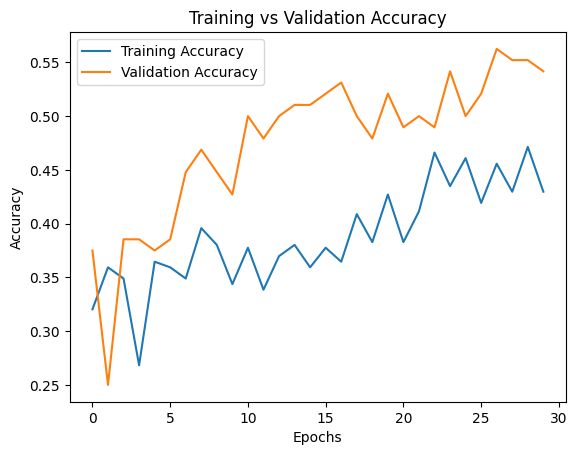

In [11]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("task3_accuracy.png")
plt.show()

In [12]:
model.save('demand_model1.keras')